# SMILES and RDKit Molecules

<div class="alert alert-block alert-info"> 
<h2>Overview</h2>

<strong>Questions:</strong>

* How are molecules represented on computers?

* What is a SMILES?
    
* What are common molecular file formats?

* What is RDKit?

* What is an RDKit molecule object?

* What can I do with RDKit molecules?

<strong>Objectives:</strong>

* Convert molecules from chemical formula and structures to SMILES strings.

* Use RDKit to create molecules in Python

</div>

## Part 1: Digital Representation of Molecules

In order to work with molecules in a programmatically, we have to be able to represent them on computers.
This can be acheived many ways. 
One way is through something called a SMILES string.
There are also file formats that represent molecules.
Examples of file formats include ``pdb``, ``mol``, ``mol2``, ``cif``, and ``mmcif``.


## Simplified Molecular-Input Line-entry System: SMILES 

SMILES stands for "Simplified Molecular-Input Line-Entry System" and is a way to represent molecules as a string of characters.

Consider the molecule ethanol. The image below shows a representation that we are used to seeing in chemistry:

![ethanol](../images/ethanol.png)

However, the SMILES representation of this molecule would be "CCO".

You can read more about SMILES at [this tutorial](https://archive.epa.gov/med/med_archive_03/web/html/smiles.html), but rules for atoms and bonds are also repeated below.

### Atoms
SMILES supports all elements in the periodic table. An atom is represented using its respective atomic symbol. Upper case letters refer to non-aromatic atoms; lower case letters refer to aromatic atoms. If the atomic symbol has more than one letter the second letter must be lower case.

### Bonds
```
-	Single bond
=	Double bond
#	Triple bond
*	Aromatic bond
.	Disconnected structures
```
Single bonds are the default and therefore need not be entered. For example, 'CC' would mean that there is a non-aromatic carbon attached to another non-aromatic carbon by a single bond, and the computer would identify the structure as the chemical ethane. It is also assumed that the bond between two lower case atom symbols is aromatic. A blank terminates the SMILES string.

### Branches

A branch from a chain is specified by placing the SMILES symbol(s) for the branch between parenthesis. Some examples:

```

CC(O)C	2-Propanol
CC(=O)C	2-Propanone
```

### Rings

A ring is specified by placing a number directly after the SMILES symbol where the ring closure occurs. This number acts as a marker, indicating that the atoms with the same number are connected, thus forming a ring. For instance:

```
C1CCCC1 cyclopentane
n1ccccc1	Pyridine
```

### SMILES Examples

<div style="text-align:center;">
  <img src="../images/smiles_example_1.png" style="display: block; margin: 0 auto; max-height:300px;">
</div>

<div style="text-align:center;">
  <img src="../images/smiles_example_2.png" style="display: block; margin: 0 auto; max-height:300px;">
</div>

### Using Online Resources
Most of the time, you will not need to write a SMILES string by hand. You will be able to look up a molecule's SMILES string from a web database like [PubChem](https://pubchem.ncbi.nlm.nih.gov/).

You can also use tools like this [molecule sketcher from the Protein Data Bank](https://www.rcsb.org/chemical-sketch)
to draw molecules and get their SMILES strings.

<div class="alert alert-block alert-warning">
<h3>Exercise</h3>

<p> Based on what you've learned about SMILES strings, answer the following questions:
<p>
    <ul>
        <li> What is the SMILES for ethanol?</li>
        <li> What is the SMILES for water?</li>
        <li> What is the SMILES for benzene?</li>
        <li> What molecule is represented by the SMILES O=C=O?</li>
        <li> What is the SMILES for an amide group?<//li>
    </ul>
</p>
<p>Check your answers from this previous exercise using the PDB molecule sketcher. Notice that you can type in a SMILES string and have the sketcher draw the molecule for you.</p>

</div>

### Fill in your answers here:

In [1]:
# Fill in your answers here:
# 1. CCO
# 2. O
# 3. c1ccccc1
# 4 carbon dioxide
# 5. C(=O)N
# 6. CC(C(=O)N)CC

## Molecular File Formats

Molecules can also be represented using a number of different file formats. As you work more in chemistry, you may see a number of these. Sometimes you will have to pick a file format based on the software you are using or the molecular information you want to save. 

| File Format | Description                                                                 | Features                                                              | Common Uses                              |
|-------------|-----------------------------------------------------------------------------|-----------------------------------------------------------------------|------------------------------------------|
| SMILES      | Simplified Molecular Input Line Entry System                                | Line notation for representing molecular structures                   | Databases, quick searches                |
| InChI       | International Chemical Identifier                                           | Textual identifier for chemical substances                            | Databases, interoperability              |
| MOL/SDF     | MDL MOLfile and Structure-Data File                                         | Contains 2D/3D coordinates, atoms, bonds                              | Structure visualization, cheminformatics |
| PDB         | Protein Data Bank format                                                    | Often used for 3D structures of proteins and nucleic acids,but can also be used for small molecules. Often does not contain molecule information, and cannot store partial charges.                           | Structural biology, bioinformatics       |
| XYZ         | Cartesian coordinates                                                       | Simple text format with atom types and 3D coordinates                 | Computational chemistry, molecular dynamics |     |
| CIF         | Crystallographic Information File                                           | Text file format for representing crystal structure data              | Crystallography                          |
| PQR         | Extended PDB format with partial charges and radii                          | Includes atomic coordinates, partial charges, and radii               | Electrostatics calculations              |
| PDBQT       | PDB format with torsion angles and charges used in AutoDock                 | Includes atomic coordinates, partial charges, torsion angles          | Molecular docking                        |
|MOL2   |Tripos Mol2 format|	Contains atomic coordinates, bonds, molecule types, substructures, and partial charges|	Molecular modeling, cheminformatics, computational chemistry




## Part 2: The RDKit Library

There are Python libraries that are made for working just with chemical data. One commonly used library in Python for data science (or cheminformatics) is called [RDKit](https://en.wikipedia.org/wiki/RDKit). RDKit is an open-source cheminformatics library, primarily developed in C++ and has been under development since the year 2000. We will be using the Python interface to RDKit, though there are interfaces in other languages.

RDKit provides a molecule object that allows you to manipulate chemical structures. It has capabilities for reading and writing molecular file formats, calculating molecular properties, and performing substructure searches. In addition, it offers a wide range of cheminformatics algorithms such as molecular fingerprint generation, similarity metrics calculation, and molecular descriptor computation. This notebook introduces RDKit basics, but we will see more of all of these topics in later notebooks.

<div class="alert alert-block alert-success"> 
<strong>Python Skills: Python Objects</strong>

Most of this functionality is achieved through the RDKit `mol` object. In Python, we use the word "object" to refer to a variable type with associated data and methods. 
One example of an object we have seen in notebooks is a list - we could also call it a "list object". An object has `attributes` (data) and `methods`. 
You access information about objects with the syntax
```python
object.data
```
where data is the attribute name.

You acceess object methods with the syntax
```python
object.method(arguments)
```

For example, for a list "`append` is a method that was covered in the introductory lesson.

```
my_list = []
my_list.append(1) # "append" is a method
```
</div>    

In this lesson, we will create and manipulate RDKit `mol` objects. RDKit `mol` objects represent molecules and have
attributes (data) and methods (actions) associated with molecules.

We are going to use a part of RDKit called `Chem`. To use `Chem`, we first have to import it. 

In [2]:
from rdkit import Chem

## Creating Molecules with RDKit

To get information about molecules in RDKit, we have to first create objects representing molecules. RDKit has molecule object that can be used to retrieve information or calculate properties. To create a molecule object, we have to communicate the molecule identity in a way that computers understand. 

We will use SMILES strings to create our objects, though RDKit also has methods for creating molecules from the file formats listed in the previous notebook.

### Creating molecules using SMILES

In the last lesson, we learned about molecular representations using SMILES strings. Now we will use SMILES strings to create molecule objects in RDKIT. 

We can create a representation of methane using RDKit by using the `MolFromSmiles` function in `rdkit.Chem`.

In [3]:
methane = Chem.MolFromSmiles("C")

The `methane` variable is now an RDKit "molecule object".

In a Jupyter environment, putting a variable that is an RDKit molecule as the only or last thing in a cell,
will result in a picture of the molecule as an output.

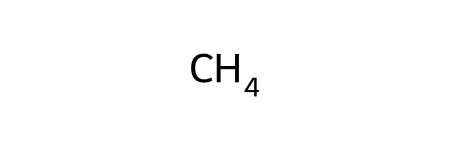

In [4]:
methane

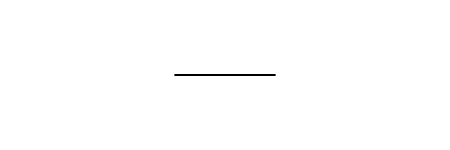

In [5]:
ethane = Chem.MolFromSmiles("CC")
ethane

<div class="alert alert-block alert-warning">
<h3>Check Your Understanding</h3>
<p> Create RDKit molecules for the following molecules. You can look up the SMILES strings on <a href="https://pubchem.ncbi.nlm.nih.gov/">PubChem</a>:
<p>
    <ul>
        <li> Propane
        <li> Ethene
        <li> Cyclohexane
        <li> Benzene </li>
        <li> Acetic Acid
    </ul>
</p>
<p>Create variables for each molecule. The variable names should be the molecule name (all lowercase)</p>
</div>


In [6]:
# Your answers go here


In [7]:
# Your answers go here
propane = Chem.MolFromSmiles("CCC")
ethene = Chem.MolFromSmiles("C=C")
cyclohexane = Chem.MolFromSmiles("C1CCCCC1")
benzene = Chem.MolFromSmiles("c1ccccc1") # a lowercase c indicates an aromatic
acetic_acid = Chem.MolFromSmiles("CC(=O)O")

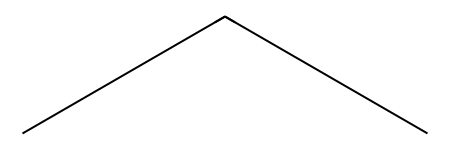

In [8]:
# Try visualizing your molecules here - you visualize a molecule as putting its variable name as the last thing in a cell
propane

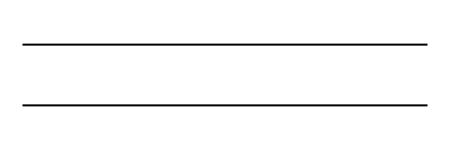

In [9]:
# Try visualizing your molecules here - you visualize a molecule as putting its variable name as the last thing in a cell
ethene

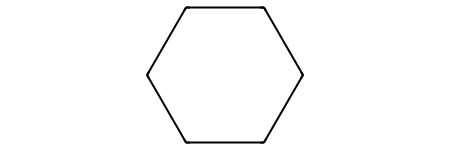

In [10]:
# Try visualizing your molecules here - you visualize a molecule as putting its variable name as the last thing in a cell
cyclohexane

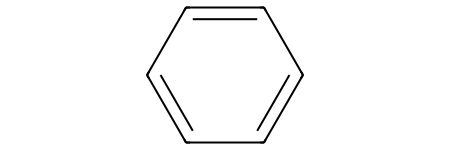

In [11]:
# Try visualizing your molecules here - you visualize a molecule as putting its variable name as the last thing in a cell
benzene

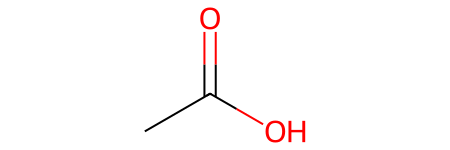

In [12]:
# Try visualizing your molecules here - you visualize a molecule as putting its variable name as the last thing in a cell
acetic_acid

## Working with RDKit Molecules

RDKit molecule objects have a number of methods we can use to get more information about the molecule.
In the next few cells, we'll look at some methods that can tell us some things about the molecules we've created.
The next cell has settings for modifying drawing molecules. It adds labels of atom indices and sets the image size.

In [13]:
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

# Configuration for displaying in Jupyter notebooks
IPythonConsole.ipython_useSVG = True  # Use SVG for higher quality images
IPythonConsole.drawOptions.addAtomIndices = True  # Show atom indices
IPythonConsole.molSize = 250,250 # Set size of image

<div class="alert alert-block alert-success"> 
<strong>Jupyter Skills: The Tab Key</strong>

When working with Python objects in the Jupyter notebook, you can type a variable or object name to see the methods available on that object.

In the cell below, type `acetic_acid.` (notice how there is a dot (`.`) at the end), then press the `tab` key. 
A list of possible methods and attributes will come up.

Look through the methods until you find one that gives you the number of atoms in the molecule.

</div>

In [14]:
# Your code goes here

In [15]:
# Pick a method that will tell you the number of
# atoms benzene has.
acetic_acid.GetNumAtoms()

4

<div class="alert alert-block alert-success"> 
<strong>Python Skills: Getting Help</strong>

Is this the number of atoms you expected for a benzene molecule? 

We can use the `help` function on the method you found in the previous step to find a method argument to figure out a method argument to get the number of atoms we expect.

</div>

In [16]:
# Write your help command here

In [17]:
help(acetic_acid.GetNumAtoms)

Help on method GetNumAtoms:

GetNumAtoms(...) method of rdkit.Chem.rdchem.Mol instance
    GetNumAtoms( (Mol)self [, (int)onlyHeavy=-1 [, (bool)onlyExplicit=True]]) -> int :
        Returns the number of atoms in the molecule.
        
          ARGUMENTS:
            - onlyExplicit: (optional) include only explicit atoms (atoms in the molecular graph)
                            defaults to 1.
          NOTE: the onlyHeavy argument is deprecated
        
    
        C++ signature :
            int GetNumAtoms(RDKit::ROMol [,int=-1 [,bool=True]])



In [18]:
# Add an argument to your function to get the number of 
# atoms that gives you the total number of atoms in acetic_acid
# including hydrogens


In [19]:
acetic_acid.GetNumAtoms(onlyExplicit=False)

8

Each molecule is made up of RDKit atom objects and RDKit bond objects.
If we want to get the atoms for a particular molecule, we can use the `GetAtoms` method.

In [20]:
acetic_acid_atoms = acetic_acid.GetAtoms()
print(acetic_acid_atoms)

<div class="alert alert-block alert-success"> 
<strong>Python Skills: Iterators</strong>

When we look at the results of the `GetAtoms` method, it tells us that we have a `GetAtomsIterator`.
In Python, an iterator is an object that contains values that can be looped through and indexed in.

Although we haven't used this terminology before, a Python list is an example of an iterator.

</div>

Like a list, we can also call `len` on the iterator.


In [21]:
len(acetic_acid_atoms)

4

Because `acetic_acid_atoms` is an iterator, we can use indexing to get a particular atom.
Atoms in RDKit molecules are represented by Atom objects.

In [22]:
atom = acetic_acid_atoms[0]
atom

When we examine one atom, we see there that there are many methods associated with the atom. 
For example, we can print the atom element or atom hybridization.

Remember, you can use the tab completion strategy you learned above to see what methods are associated with any RDKit object.

In [23]:
print(atom.GetSymbol())
print(atom.GetHybridization())

C
SP3


We can use a for loop to give information about each atom.

In [24]:
# Atom will be each atom in the acetic_acid_atoms iterator
for atom in acetic_acid_atoms:
    symbol = atom.GetSymbol()
    hybridization = atom.GetHybridization()
    print(f"Atom {symbol} has hybridization {hybridization}")

Atom C has hybridization SP3
Atom C has hybridization SP2
Atom O has hybridization SP2
Atom O has hybridization SP2


Bonds are also objects in RDKit, and we ca iterate over them the same way we can iterate over atoms.

In [25]:
acetic_acid_bonds = acetic_acid.GetBonds()
bond = acetic_acid_bonds[0]

In [26]:
bond.GetBondType()

rdkit.Chem.rdchem.BondType.SINGLE

<div class="alert alert-block alert-warning"> 
<h3>Challenge</h3>

Use a `for` loop to print information about each bond.
For each bond, you should print the starting atom symbol, the ending atom symbol,
and the bond type. Use your tab completion strategy to find the appropriate methods for the bond objects to give you this information.

Your output should look like the following:

```
Bond between C and C is a SINGLE bond.
Bond between C and O is a DOUBLE bond.
Bond between C and O is a SINGLE bond.
```

</div>

In [27]:
# Your code goes here


In [28]:
# Note to instructors: this is hard for them, give at least 15 minutes
for bond in acetic_acid_bonds:
    atom1 = bond.GetBeginAtom().GetSymbol()
    atom2 = bond.GetEndAtom().GetSymbol()
    print(f"Bond between {atom1} and {atom2} is a {bond.GetBondType()} bond.")

Bond between C and C is a SINGLE bond.
Bond between C and O is a DOUBLE bond.
Bond between C and O is a SINGLE bond.


## Editing Atoms with RDKit

In addition to seeing information about atoms and bonds in our molecule, we can also use RDKit to change our molecule structure. 
Let's consider benzene for our example. We will change one of the carbons in the benzene ring to a nitrogen to make pyridine.

We are going to create a copy of our benzene molecule using another function from RDKit called `RWMol`. `RWMol` makes our molecule readable and writeable (or "editable").

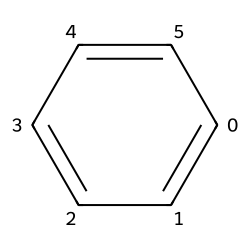

In [29]:
pyridine = Chem.RWMol(benzene)
pyridine

One way we can change molecules in RDKit is to set the atomic number of a particular atom to another number. 
To change one of the carbons in our ring to nitrogen, we can select one of the atoms and then set its atomic number to that of nitrogen (7).

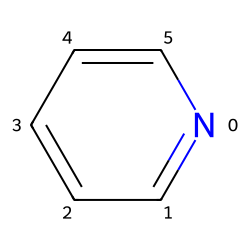

In [30]:
atom = pyridine.GetAtomWithIdx(0) # Get atom with index 0 (labeled 0 above)
atom.SetAtomicNum(7) # Set the atomic number to 7
pyridine

In [31]:
# Now I can go backwards and make a SMILES for this new molecule object
Chem.MolToSmiles(pyridine)

'c1ccncc1'

<div class="alert alert-block alert-warning"> 
<h3>Challenge</h3>

Change another atom in the pyridine ring to create [pyrimidine](https://en.wikipedia.org/wiki/Pyrimidine).

</div>

In [32]:
# Your code goes here; you can add additional code cells if needed

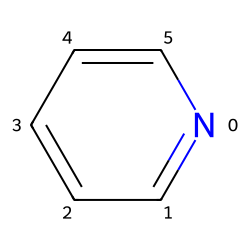

In [33]:
pyrimidine = Chem.RWMol(pyridine)
pyrimidine

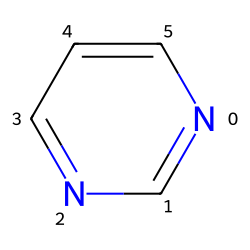

In [34]:
atom = pyrimidine.GetAtomWithIdx(2) # Get atom with index 0 (labeled 0 above)
atom.SetAtomicNum(7) # Set the atomic number to 7
pyrimidine

## Combining two molecules

We can also create and combine molecules using RDKit. This approach might be necessary when we want to add a more complex functional group. In the example below we create a carboxyl group and add it to benzene to make benzoic acid.

First we create the molecule for our functional group.

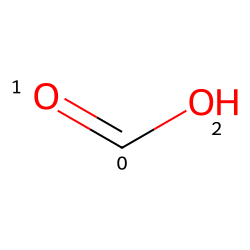

In [35]:
carboxyl = Chem.MolFromSmiles("C(=O)O")
carboxyl

Next, we combine the two molecules together using the `CombineMols` function.

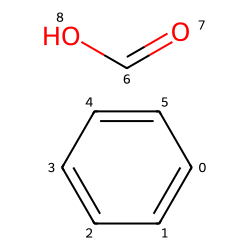

In [36]:
combined = Chem.CombineMols(benzene, carboxyl)
combined

After the combining, we have to make our combined molecules editable so that we can change the bonds and atoms.

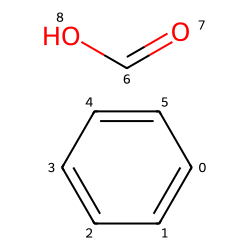

In [37]:
editable_mol = Chem.RWMol(combined)
editable_mol

Finally, we can use `AddBonds` to add a bond between the carbon on our carboxyl group (6) to an atom on benzene. We could have picked any carbon, but the example below uses index 5.

In [38]:
editable_mol.AddBond(5, 6, order=Chem.rdchem.BondType.SINGLE)

9

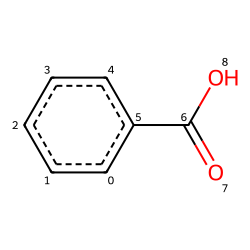

In [39]:
editable_mol

<div class="alert alert-block alert-info"> 
<strong>Molecular Sanitization</strong>

When a molecule is loaded into RDKit, a ["molecular sanitization"](https://www.rdkit.org/docs/RDKit_Book.html#molecular-sanitization) step typically takes place.
Molecular sanitization ensures that molecules are "reasonable":that they can be represented with octet-complete Lewis dot structures.
</div>

After we add new atoms like this, our molecule usually needs to be "sanitized". One way we can tell this is by viewing the molecule above. Our aromatic ring structure is now symbolized with a dotted line inside of the ring. We will want to use the `Chem.SanitizeMol` method to sanitize the molecule.
The step of sanitiziation that is important in this case is the `Kekulize` step, where aromatic rings are converted to the Kekule form. A Python error (exception) would occur if a problem is found with aromaticity. 

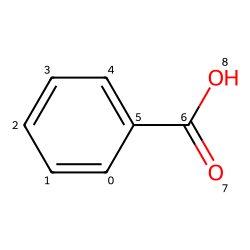

In [40]:
Chem.SanitizeMol(editable_mol)
editable_mol

<div class="alert alert-block alert-warning"> 
<h2>Final Activity</h2>

[Protein phoshorylation](https://www.thermofisher.com/us/en/home/life-science/protein-biology/protein-biology-learning-center/protein-biology-resource-library/pierce-protein-methods/phosphorylation.html) refers to the additon of a phosphate group to the -OH group of an amino acid and occurs for serine, threonine, or tyrosine residues.

For this challenge, you should modify the tyrosine module (given below) to add a phosphate to the OH group. 

</div>

In [41]:
# Your code goes here
tyrosine = Chem.MolFromSmiles("C1=CC(=CC=C1CC(C(=O)O)N)O")


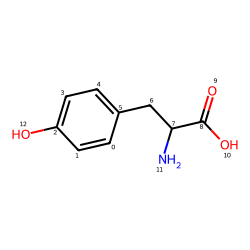

In [42]:
tyrosine = Chem.MolFromSmiles("C1=CC(=CC=C1CC(C(=O)O)N)O")
tyrosine = Chem.RWMol(tyrosine)
tyrosine

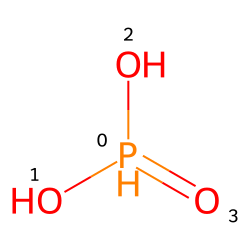

In [43]:
phosphate = Chem.MolFromSmiles("P(O)(O)(=O)")
phosphate

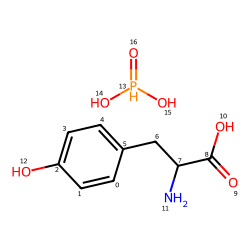

In [44]:
combined_mols = Chem.RWMol(Chem.CombineMols(tyrosine, phosphate))
combined_mols

In [45]:
combined_mols.AddBond(12, 13, order=Chem.rdchem.BondType.SINGLE)

17

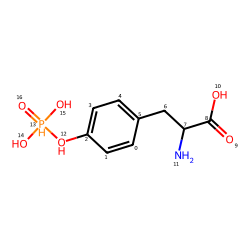

In [46]:
combined_mols

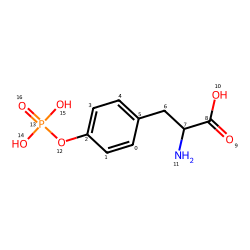

In [47]:
Chem.SanitizeMol(combined_mols)
combined_mols

In [51]:
#This is the code cell that makes the student version
# Go to Edit --> Clear Outputs of all cells
# Save the notebook
# Change the file name in the nbconvert line to the relevant thing
# Fill in the output filename with the student-version-filename
# Run this cell
# This cell is itself deleted in the student notebook
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"solution\"\] \
    --output student.ipynb

/Users/armcdona/anaconda3/lib/python3.11/site-packages/traitlets/traitlets.py:2915: FutureWarning: --TagRemovePreprocessor.remove_cell_tags=["solution"] for containers is deprecated in traitlets 5.0. You can pass `--TagRemovePreprocessor.remove_cell_tags item` ... multiple times to add items to a list.
  warn(
[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 32457 bytes to student.ipynb
